# Figure 3: TargetGAN Performance and Evaluation of Activity-Targeted Synthetic Promoters (SPs)

This notebook generates the panels for **Figure 3**, which evaluate how well TargetGAN can generate functional promoters at specified activity levels and how closely the resulting synthetic promoters resemble natural promoter sequences.

The analyses are organized into six main sections:

1.  **Iterative Optimization Toward Activity Targets**: Visualizing optimization trajectories for nine targets (Max, 2, 1, 0, -1, -2, -3, -4, Min).
2.  **Activity Target Accuracy**: Quantifying the fraction of generated promoters that fall within each predefined target window based on predictor outputs.
3.  **Robustness Across Replicates**: Assessing run-to-run stability across multiple independent seeds for each activity target level.
4.  **Sequence Grammar Similarity**: Comparing **6-mer frequency** profiles between Natural Promoters (NPs) and TargetGAN Synthetic Promoters (SPs), including target-wise correlations.
5.  **Overall Diversity, Composition, and DNA Shape Features**: Evaluating **Jaccard distance**, **Levenshtein distance**, **GC content**, and DNA structural features (**MGW**, **Roll**, **HelT**, **ProT**) to assess diversity and biological realism.
6.  **Target-wise Diversity, Composition, and DNA Shape Analysis**: Repeating diversity/composition metrics and DNA shape comparisons **separately for each activity target** to check whether any target-specific shifts emerge.

## Import Required Packages and Configure Environment

In [6]:
import os
# Specify CUDA device before importing tensorflow
os.environ["CUDA_VISIBLE_DEVICES"] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import warnings
import importlib
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.image as mpimg
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import pearsonr
import tensorflow as tf
from tensorflow import keras

# Custom utils
import utils
from utils import one_hot_encode, suppress_tf_warnings, accumulate_kmer_frequencies, gc_content, jaccard_distance

# Configure Plotting Style
# Font settings
font_path = '/home/xlxiang/miniconda3/ARIAL.TTF'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Arial'
else:
    print(f"Warning: Font file not found at {font_path}")
    plt.rcParams['font.sans-serif'] = ['Arial']
    plt.rcParams['font.family'] = 'sans-serif'

plt.rcParams['svg.fonttype'] = 'none' 
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.linewidth'] = 0.75

# Suppress warnings
warnings.filterwarnings('ignore')
suppress_tf_warnings()

## 3.1. Visualization of the Iterative Optimization Process
Visualizing the iterative optimization trajectories toward each target activity level using the logged optimization curves for a representative seed.

--- Optimization Progress (Seed 2023) ---


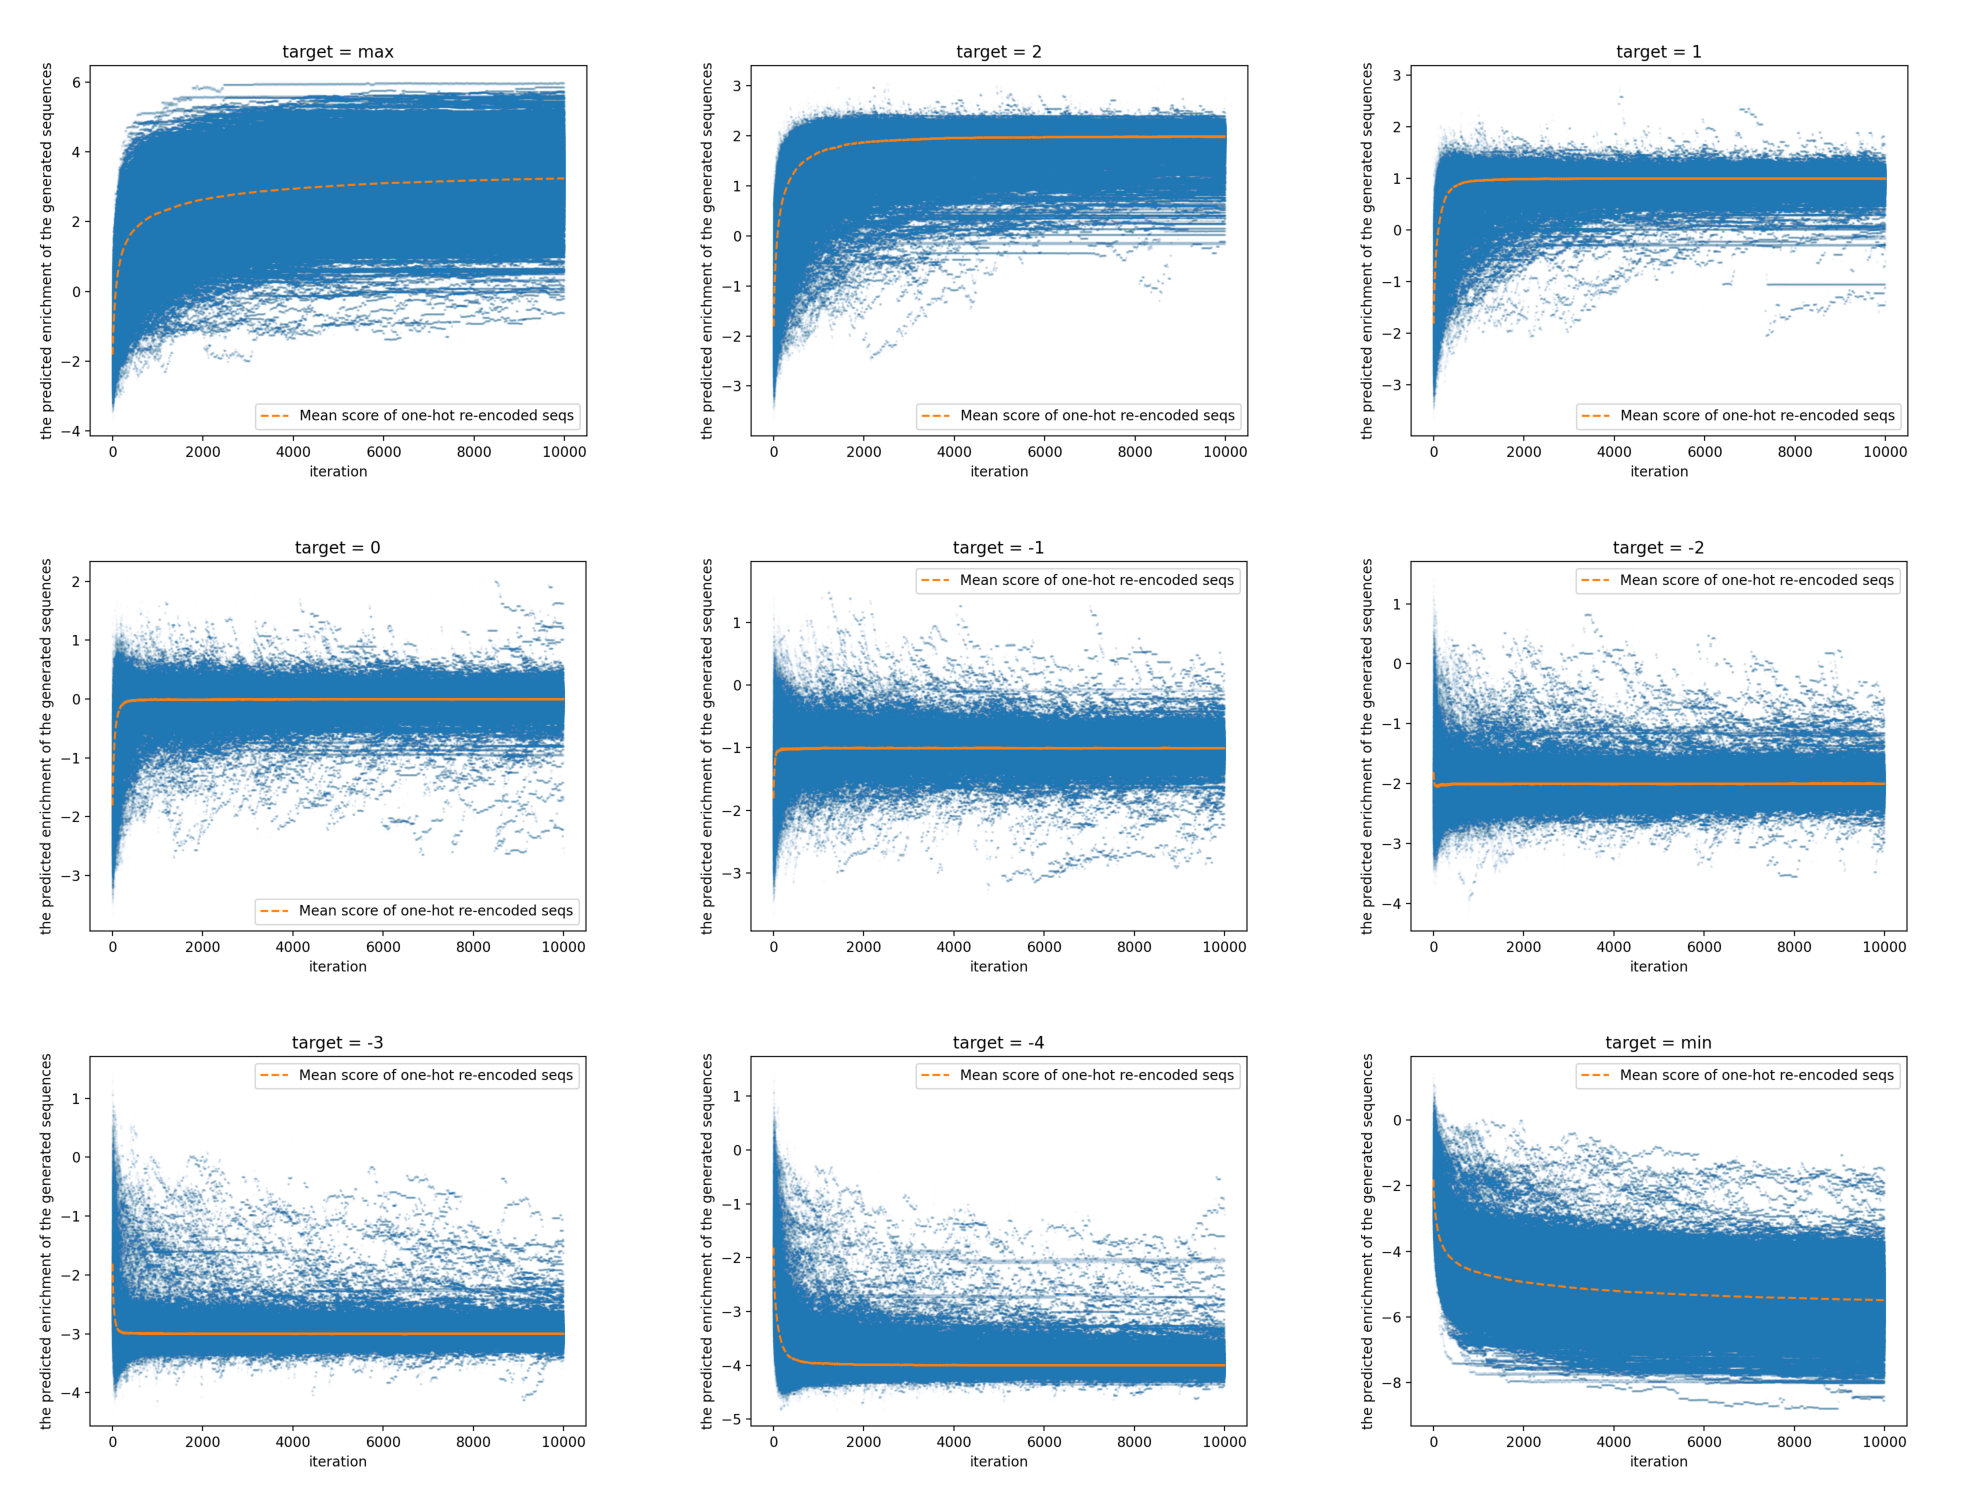

In [7]:
# Define the targets in order
targets_map = [
    ("max", "Target = Max"),
    ("2", "Target = 2"),
    ("1", "Target = 1"),
    ("0", "Target = 0"),
    ("-1", "Target = -1"),
    ("-2", "Target = -2"),
    ("-3", "Target = -3"),
    ("-4", "Target = -4"),
    ("min", "Target = Min")
]
seed = "2023"
logs_dir = "../targetgan-logs"

# Create a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

print(f"--- Optimization Progress (Seed {seed}) ---")

for i, (prefix, label) in enumerate(targets_map):
    # Construct image path
    img_path = os.path.join(logs_dir, f"target_{prefix}_seed_{seed}", "scores_opt.png")
    
    ax = axes[i]
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off') # Turn off axes since the image likely contains them
    else:
        ax.text(0.5, 0.5, f"Image not found:\n{img_path}", ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()

## 3.2. Accuracy of TargetGAN in Generating Activity-Specific Promoters
Quantifying how often TargetGAN-generated promoters achieve the predefined activity targets, based on the predictor model's log$_2$(activity) estimates.

--- Activity Target Percentage (Seed 2023) ---
Target = Max: 63.6%
Target = 2: 68.1%
Target = 1: 79.8%
Target = 0: 77.4%
Target = -1: 71.0%
Target = -2: 70.8%
Target = -3: 80.7%
Target = -4: 75.4%
Target = Min: 24.9%


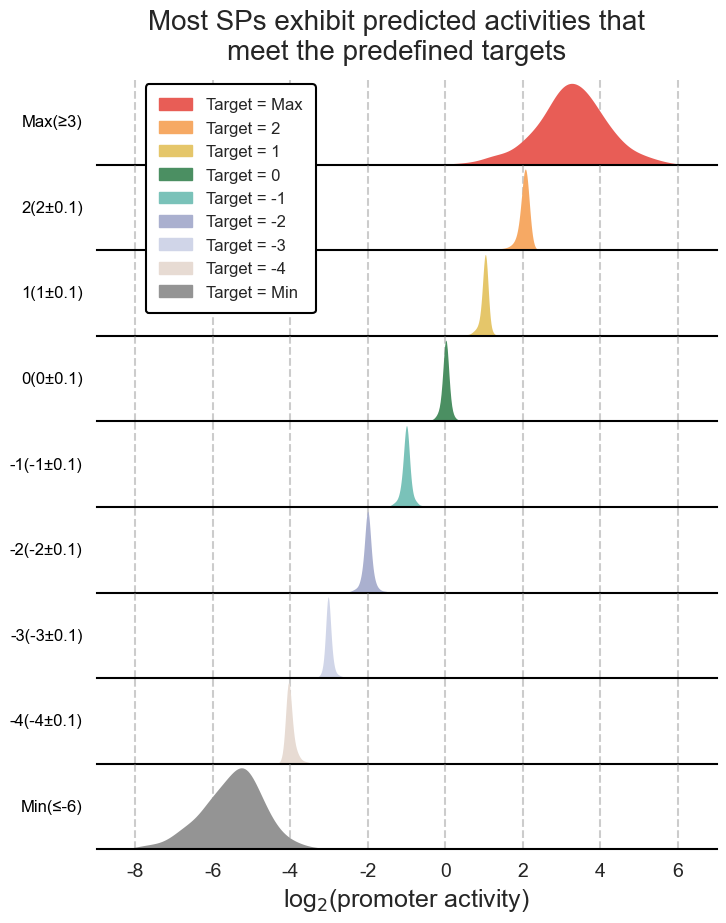

In [8]:
# 1. Load Predictor
model_path = '../data/predictor.h5'
if not os.path.exists(model_path):
    model_path = '/home/xlxiang/TargetGAN-main/data/predictor.h5'
model = keras.models.load_model(model_path)

# 2. Configuration
targets_config = [
    ("Max(≥3)", "max", lambda x: x >= 3.0, "Target = Max"),
    ("2(2±0.1)", "2", lambda x: (x >= 1.9) & (x <= 2.1), "Target = 2"),
    ("1(1±0.1)", "1", lambda x: (x >= 0.9) & (x <= 1.1), "Target = 1"),
    ("0(0±0.1)", "0", lambda x: (x >= -0.1) & (x <= 0.1), "Target = 0"),
    ("-1(-1±0.1)", "-1", lambda x: (x >= -1.1) & (x <= -0.9), "Target = -1"),
    ("-2(-2±0.1)", "-2", lambda x: (x >= -2.1) & (x <= -1.9), "Target = -2"),
    ("-3(-3±0.1)", "-3", lambda x: (x >= -3.1) & (x <= -2.9), "Target = -3"),
    ("-4(-4±0.1)", "-4", lambda x: (x >= -4.1) & (x <= -3.9), "Target = -4"),
    ("Min(≤-6)", "min", lambda x: x <= -6.0, "Target = Min")
]

# Custom color palette matching the image
colors = [
    "#E85D56", # Max - Salmon/Red
    "#F6A964", # 2 - Orange
    "#E5C66A", # 1 - Yellow/Gold
    "#4B8F62", # 0 - Green
    "#7AC2B9", # -1 - Teal
    "#AAB0CF", # -2 - Lavender/Grey
    "#D0D5E8", # -3 - Light Blue/Grey
    "#E7DBD3", # -4 - Beige/Grey
    "#949494"  # Min - Grey
]

logs_dir = '../targetgan-logs'
target_seed = '2023'
results = []

# 3. Process Data
print(f"--- Activity Target Percentage (Seed {target_seed}) ---")
for idx, (axis_label, prefix, criteria, legend_label) in enumerate(targets_config):
    folder_name = f"target_{prefix}_seed_{target_seed}"
    file_path = os.path.join(logs_dir, folder_name, 'last_seq.txt')
    
    if not os.path.exists(file_path):
        continue
    
    with open(file_path, 'r') as f:
        sequences = [line.strip() for line in f if line.strip()]
    
    if not sequences:
        continue

    # Predict
    one_hots = np.array([one_hot_encode(s) for s in sequences])
    preds = model.predict(one_hots, verbose=0, batch_size=256).squeeze()
    
    # Calculate Stats
    matches = criteria(preds)
    pct = np.mean(matches) * 100
    
    # Print percentage as requested
    print(f"{legend_label}: {pct:.1f}%")
    
    results.append({
        'data': preds,
        'axis_label': axis_label,
        'legend_label': legend_label,
        'pct': pct,
        'color': colors[idx],
        'target_val': prefix 
    })

# 4. Plotting (Ridge Plot / Joy Plot)
# Use exact spacing hspace=0 to make them touch like the reference
fig, axes = plt.subplots(len(results), 1, figsize=(8, 10), sharex=True, gridspec_kw={'hspace': 0})

for i, res in enumerate(results):
    ax = axes[i]
    data = res['data']
    color = res['color']
    
    # KDE Plot
    # Fill opacity 1.0 to match the solid look in "Desired" image
    sns.kdeplot(data, ax=ax, fill=True, color=color, alpha=1.0, linewidth=0, bw_adjust=1.5)
    
    # Grid lines (Vertical only)
    # Using zorder=0 to put grid behind the plot
    for x in range(-8, 8, 2):
        ax.axvline(x, linestyle='--', linewidth=1.5, color='gray', alpha=0.4, zorder=0)
    
    # Adjust axes visibility
    ax.set_facecolor('none')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Bottom spine: Make it black and solid for every track
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    
    # Remove y ticks
    ax.set_yticks([])
    
    # Add Y-label (rows) on the left
    ax.set_ylabel(res['axis_label'], rotation=0, ha='right', va='center', fontsize=12, color='black', labelpad=10)

# X-axis configuration
axes[-1].set_xlabel('log$_2$(promoter activity)', fontsize=18)
axes[-1].tick_params(axis='x', labelsize=14, length=6, width=1.5)
axes[-1].set_xlim(-9, 7)
# Ensure x-ticks match the grid/image (-8 to 6 usually)
axes[-1].set_xticks(range(-8, 8, 2))

# Overall Title
fig.suptitle('Most SPs exhibit predicted activities that\nmeet the predefined targets', 
             fontsize=20, fontweight='bold', y=0.95)

# Legend
# Create custom handles for the legend
legend_handles = [Patch(color=res['color'], label=res['legend_label']) for res in results]

# Place legend in the figure coordinates to float over the top-left area
legend = fig.legend(handles=legend_handles, 
                    loc='upper left', 
                    bbox_to_anchor=(0.18, 0.88), # Adjust x, y to fit in the empty space
                    frameon=True, 
                    edgecolor='black', 
                    framealpha=1, 
                    fontsize=12, 
                    labelspacing=0.5,
                    borderpad=0.6)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_boxstyle("Round,pad=0.2") # Optional rounded corners
plt.show()

## 3.3. Robustness and Stability of TargetGAN Across Replicates
Assessing run-to-run stability by comparing predicted activity distributions across multiple independent training runs (seeds) for each activity target.

Gathering data from replicates...


Data loaded. Plotting...


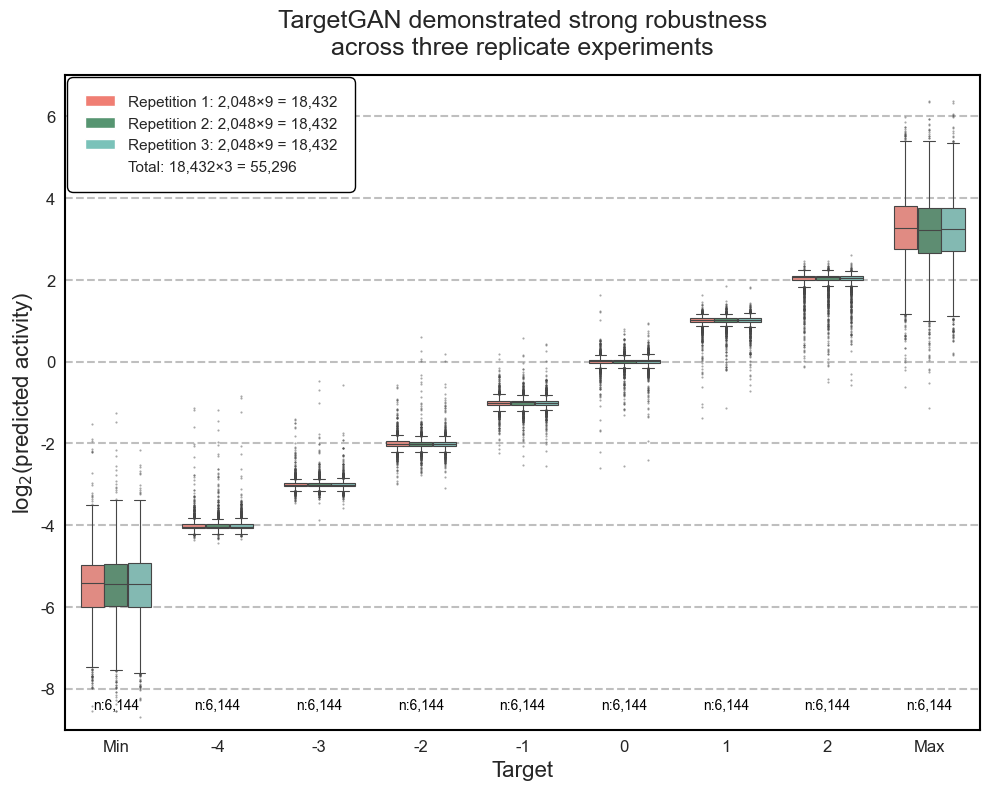

In [9]:
# --- Robustness Analysis (Seeds 2023, 2024, 2025) ---

# Config
seeds = ['2023', '2024', '2025']
rep_names = ['Repetition 1', 'Repetition 2', 'Repetition 3'] # Corrected spelling
targets_order = ['min', '-4', '-3', '-2', '-1', '0', '1', '2', 'max']
x_tick_labels = ['Min', '-4', '-3', '-2', '-1', '0', '1', '2', 'Max']
colors_list = ['#F07E73', # Salmon
               '#569571', # Green
               '#7AC2B9'] # Teal/Light Blue (Matching image approx)

data_rows = []

print("Gathering data from replicates...")

for t_idx, prefix in enumerate(targets_order):
    for s_idx, seed in enumerate(seeds):
        # Construct path
        folder = f"target_{prefix}_seed_{seed}"
        path = os.path.join(logs_dir, folder, 'last_seq.txt')
        
        preds = []
        if os.path.exists(path):
            with open(path, 'r') as f:
                # Filter empty lines
                seqs = [line.strip() for line in f if line.strip()]
            
            if seqs:
                # Predict in batches
                # Reuse 'model' from previous cells
                one_hots = np.array([one_hot_encode(s) for s in seqs])
                preds = model.predict(one_hots, verbose=0, batch_size=2048).flatten()
        
        # Add to dataset
        for score in preds:
            data_rows.append({
                'Target': x_tick_labels[t_idx], # Use display label for grouping
                'Repetition': rep_names[s_idx],
                'Score': score,
                'SortIndex': t_idx # For sorting
            })

# Create DataFrame
df_rob = pd.DataFrame(data_rows)

if not df_rob.empty:
    print("Data loaded. Plotting...")
    
    plt.figure(figsize=(10, 8))
    sns.set_style("white")
    
    # Create Boxplot
    ax = sns.boxplot(data=df_rob, x='Target', y='Score', hue='Repetition', 
                     palette=colors_list, 
                     showfliers=True, 
                     flierprops={'marker': '.', 'markersize': 1, 'alpha': 0.5},
                     linewidth=0.8,
                     width=0.7)
    
    # Grid lines
    ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.5, linewidth=1.5)
    ax.set_axisbelow(True)
    
    # Titles and Labels
    plt.title('TargetGAN demonstrated strong robustness\nacross three replicate experiments', 
              fontsize=18, fontweight='bold', y=1.02)
    plt.xlabel('Target', fontsize=16)
    plt.ylabel('log$_2$(predicted activity)', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Calculate counts for Legend and Annotations
    counts = df_rob.groupby('Repetition')['Score'].count()
    rep_counts = [counts.get(r, 0) for r in rep_names]
    # Sample calculation string: "2,048x9 = 18,432"
    # Assuming standard count. If counts vary, this might be approximate text.
    # We'll use the first target of the first rep to guess the specific batch size if needed, 
    # or just use the total / 9.
    
    legend_texts = []
    total_samples = sum(rep_counts)
    for i, r_name in enumerate(rep_names):
        c = rep_counts[i]
        # Infer individual batch size (approx)
        batch = c // 9 
        legend_texts.append(f"{r_name}: {batch:,}×9 = {c:,}")
    
    legend_texts.append(f"Total: {rep_counts[0]:,}×3 = {total_samples:,}")

    # Custom Legend Box
    handles = [Patch(facecolor=colors_list[i], label=legend_texts[i]) for i in range(3)]
    # Add invisible handle for Total
    from matplotlib.lines import Line2D
    handles.append(Line2D([0], [0], color='none', label=legend_texts[3]))
    
    leg = ax.legend(handles=handles, loc='upper left', fontsize=11, 
                    frameon=True, edgecolor='black', framealpha=1, borderpad=0.8)
    leg.get_frame().set_boxstyle("Round,pad=0.4")
    
    # Annotate 'n: ...' at the bottom of each group
    # We need the count per target (summing all reps)
    total_per_target = df_rob.groupby('Target')['Score'].count()
    # Sort by the x-axis order
    target_ns = [total_per_target.get(t, 0) for t in x_tick_labels]
    
    # Get y-axis limits to position text
    y_min, y_max = ax.get_ylim()
    # Position slightly above the bottom spine or at specific data coord
    # Image shows labels just above the x-axis labels. 
    # Let's verify the data range. Min target looks like -8ish.
    # We can place text at y = -7.5 roughly if data goes to -8.
    
    text_y_pos = y_min + (y_max - y_min) * 0.02 # Just above bottom
    # Or fixed if we know the scale. Let's try to find a gap.
    # Actually, seaborn/mpl puts labels outside? No, inside in the reference image.
    
    # Adjust Y limit to make room for annotations if needed
    ax.set_ylim(bottom=-9, top=7) 
    
    for i, count in enumerate(target_ns):
        ax.text(i, -8.5, f"n:{count:,}", ha='center', fontsize=10, color='black')

    # Border frame
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

    plt.tight_layout()
    plt.show()
else:
    print("No data found for the specified seeds and targets.")

### Predicted Activity Distribution (Natural vs. TargetGAN-SPs)
Comparing the predicted activity distribution of TargetGAN synthetic promoters against natural promoters using the same activity predictor model.

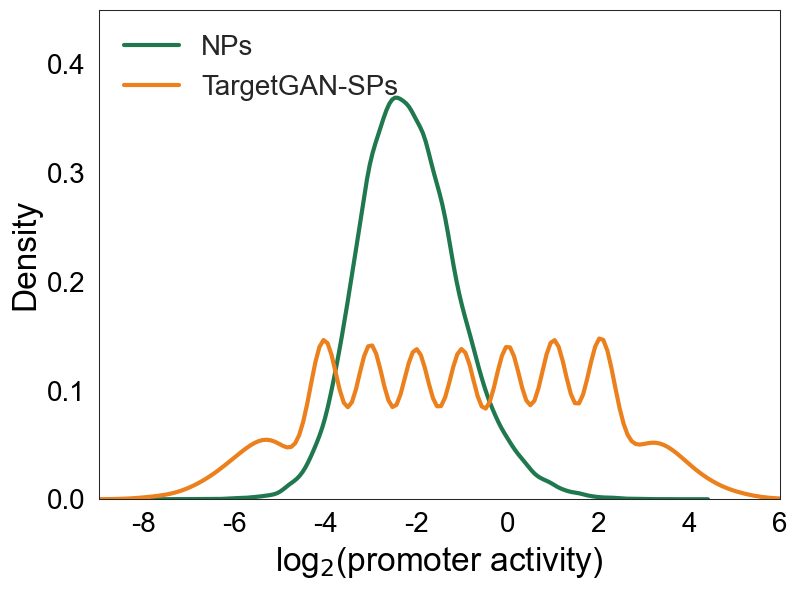

In [10]:
# Load model
model_path = '../data/predictor.h5'
model = keras.models.load_model(model_path)

# Load Data
# Natural
# Ensure we use the correct file path
data_np_path = '../data/Natural_promoters.xlsx'
data_np = pd.read_excel(data_np_path)
activities_np = data_np['enrichment'].values

# Synthetic (TargetGAN)
target_path = '../data/targetgan_55296.xlsx'

data_sp = pd.read_excel(target_path)
sp_sequences = data_sp['sequence'].dropna().tolist()

# Predict if not already (or load if saved)
# Using the loaded model to predict activities for the generated sequences
sp_onehot = np.array([one_hot_encode(seq) for seq in sp_sequences])
# Batch prediction for speed
predicted_activities_sp = model.predict(sp_onehot, verbose=0, batch_size=2048)
activities_sp = np.squeeze(predicted_activities_sp)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Border width settings
plt.rcParams['axes.linewidth'] = 2

# Plot KDEs with specific colors and labels matching the request
# NPs: Dark Green, TargetGan-SPs: Orange
sns.kdeplot(activities_np, color="#1f784e", linewidth=3, label='NPs', ax=ax)
sns.kdeplot(activities_sp, color="#eb801c", linewidth=3, label='TargetGAN-SPs', ax=ax)

# Styling
# Remove title as per image style
ax.set_title('') 

# Labels with math text
ax.set_xlabel(r'log$_2$(promoter activity)', fontsize=24, color='black')
ax.set_ylabel('Density', fontsize=24, color='black')

# Limits matched to the image
ax.set_xlim(-9, 6) 
ax.set_ylim(0, 0.45) 

# Ticks styling
ax.tick_params(axis='both', which='major', labelsize=20, width=2, length=6, colors='black')

# Legend
legend = ax.legend(frameon=False, fontsize=20, loc='upper left')

plt.tight_layout()
plt.show()

## 3.4. K-mer Frequency Correlation between NPs and SPs
Scatter plot comparison of **6-mer** frequencies between all natural promoters and TargetGAN synthetic promoters to assess motif-level similarity and highlight TATA-box conservation.

Counts - Natural: 76851, Synthetic: 55296


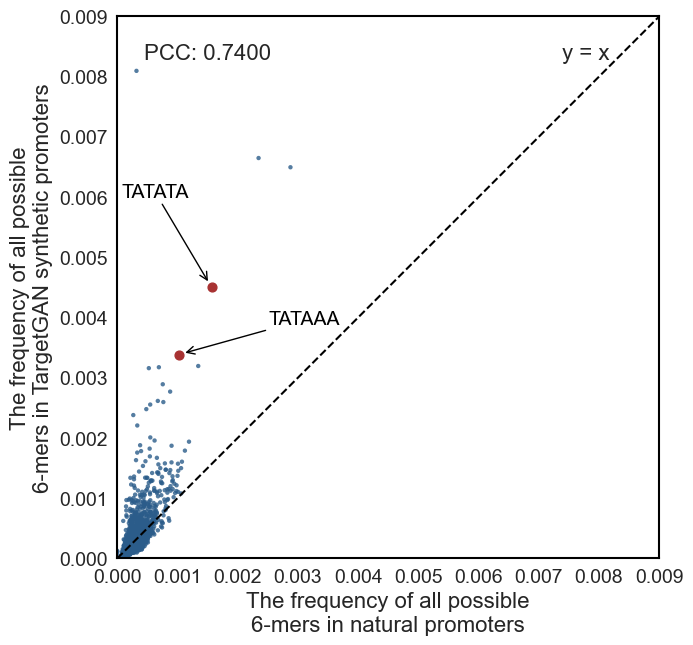

In [11]:
# 1. Load Data
natural_path = '../data/Natural_promoters.xlsx'
target_path = '../data/targetgan_55296.xlsx'

# Read Excel Files
df_nat = pd.read_excel(natural_path)
df_syn = pd.read_excel(target_path)


# Synthetic: User confirmed column is 'sequence'
# Natural: Using all NPs as requested, assuming 'sequence' column exists
natural_seqs = list(df_nat.sequence.dropna())
generated_seqs = list(df_syn.sequence.dropna())

print(f"Counts - Natural: {len(natural_seqs)}, Synthetic: {len(generated_seqs)}")

# 2. Calculate 6-mer Frequencies
k = 6
accumulated_vector_natural = accumulate_kmer_frequencies(natural_seqs, k)
accumulated_vector_generated = accumulate_kmer_frequencies(generated_seqs, k)

# 3. Calculate Pearson Correlation
pcc, _ = pearsonr(accumulated_vector_natural, accumulated_vector_generated)

# 4. Identify indices for TATA boxes
bases = ['A', 'T', 'C', 'G']
kmer_all = reduce(lambda x,y: [i+j for i in x for j in y], [bases] * k)
idx_tataaa = kmer_all.index('TATAAA')
idx_tatata = kmer_all.index('TATATA')

# 5. Plotting
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal')

# Scatter Plot
ax.scatter(accumulated_vector_natural, accumulated_vector_generated, 
           s=10, c='#2b5c8a', alpha=0.8, edgecolors='none', label='6-mers')

# Diagonal Line
limit = 0.009 # Limit adjusted to cover the full range of all NPs
ax.plot([0, limit], [0, limit], 'k--', linewidth=1.5, label='y = x')

# Highlight TATA
highlight_color = '#a83232'
# Use indices to get coordinates
x_tataaa, y_tataaa = accumulated_vector_natural[idx_tataaa], accumulated_vector_generated[idx_tataaa]
x_tatata, y_tatata = accumulated_vector_natural[idx_tatata], accumulated_vector_generated[idx_tatata]

ax.scatter(x_tataaa, y_tataaa, s=40, c=highlight_color, zorder=10)
ax.scatter(x_tatata, y_tatata, s=40, c=highlight_color, zorder=10)

# Annotations
ax.text(0.05, 0.92, f'PCC: {pcc:.4f}', transform=ax.transAxes, fontsize=16, fontweight='bold')
ax.text(0.82, 0.92, 'y = x', transform=ax.transAxes, fontsize=16)

# Arrows
ax.annotate('TATAAA', 
            xy=(x_tataaa, y_tataaa), 
            xytext=(x_tataaa + 0.0015, y_tataaa + 0.0005),
            fontsize=14, fontweight='bold', color='black',
            arrowprops=dict(color='black', arrowstyle='->', shrinkA=0, shrinkB=5))

ax.annotate('TATATA', 
            xy=(x_tatata, y_tatata), 
            xytext=(x_tatata - 0.0015, y_tatata + 0.0015),
            fontsize=14, fontweight='bold', color='black',
            arrowprops=dict(color='black', arrowstyle='->', shrinkA=0, shrinkB=5))

# Labels and Title
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel('The frequency of all possible\n6-mers in natural promoters', fontsize=16)
ax.set_ylabel('The frequency of all possible\n6-mers in TargetGAN synthetic promoters', fontsize=16)
# ax.set_title('6-mer Frequency Correlation', fontsize=20, fontweight='bold', pad=20)

# Explicitly set all spines to be visible and have consistent width
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

ax.tick_params(width=1.5, labelsize=14)

plt.tight_layout()
plt.show()

### Sequence Diversity and Composition Comparison
Distributions of Jaccard distance, Levenshtein distance, and GC content for the TargetGAN synthetic set compared to natural promoters.

**Note:** Run `python jaccard_levenshtein_distance_GAN_TargetGAN.py` beforehand to compute the distance metrics between TargetGAN-generated promoters and NPs, and to generate the required `.npy` files under `./data_for_plot/` (e.g., `test_jaccard.npy`, `target_jaccard.npy`, `test_levenshtein.npy`, `target_levenshtein.npy`).

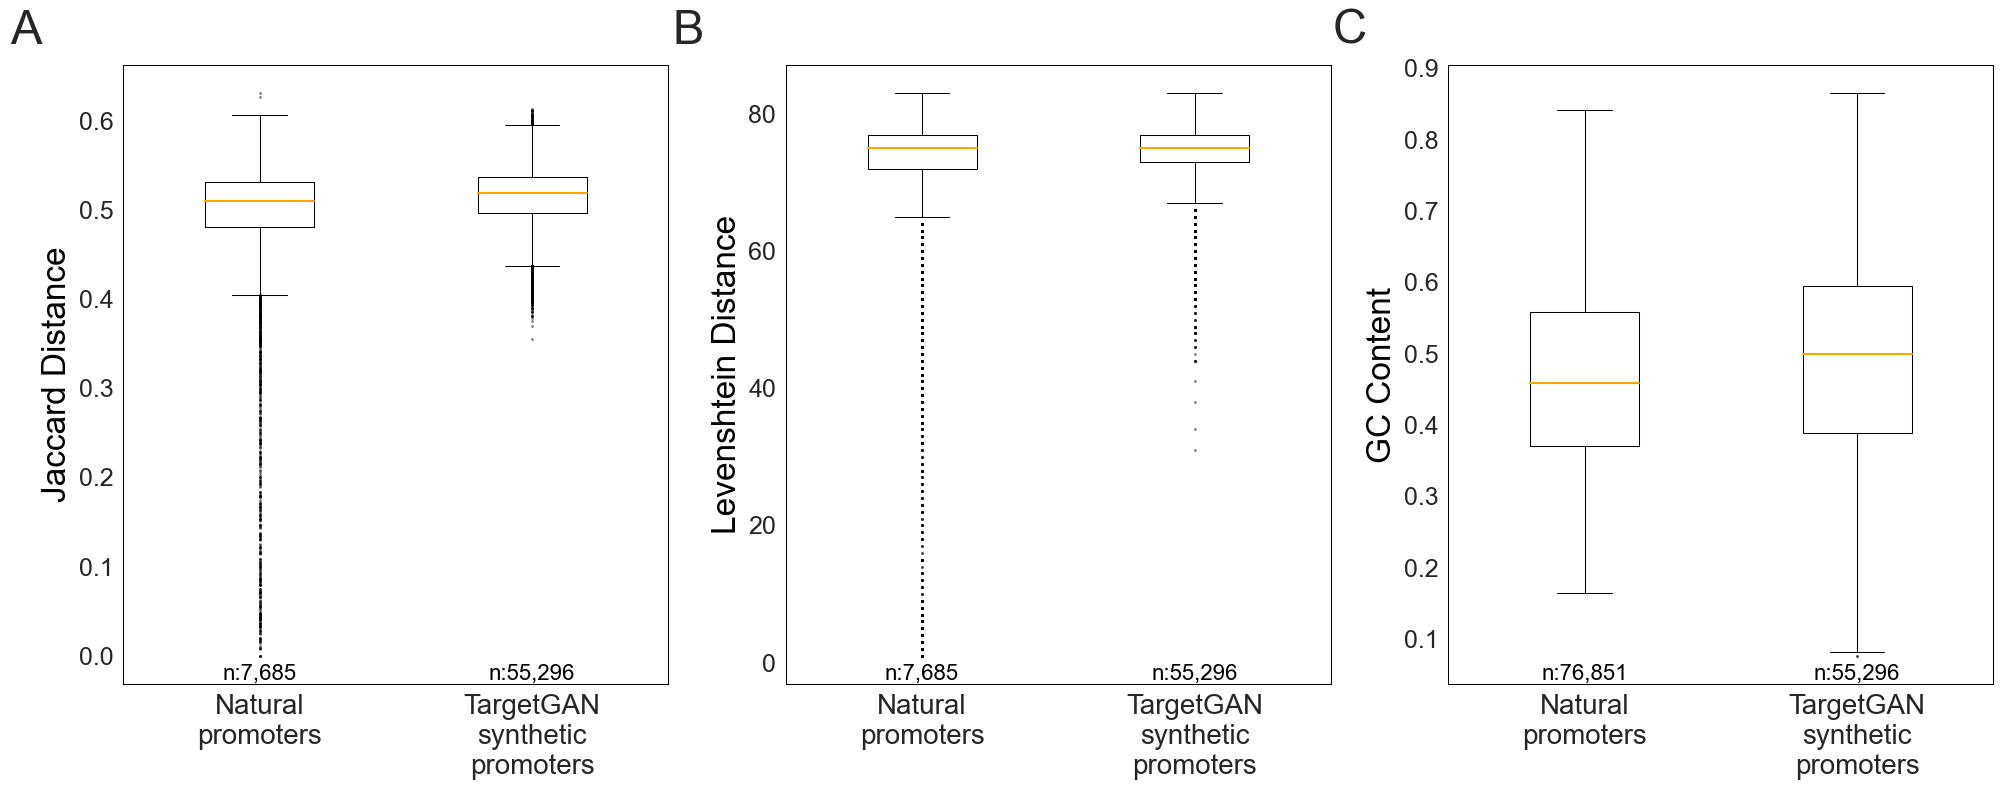

In [12]:
# Configuration
save_dir = './data_for_plot'

# Load Data
# (1) Jaccard & Levenshtein
test_jaccard = np.load(os.path.join(save_dir, 'test_jaccard.npy'))
target_jaccard = np.load(os.path.join(save_dir, 'target_jaccard.npy'))
test_levenshtein = np.load(os.path.join(save_dir, 'test_levenshtein.npy'))
target_levenshtein = np.load(os.path.join(save_dir, 'target_levenshtein.npy'))

# (2) GC Content
def get_gc_list(sequences):
    return [gc_content(seq) for seq in sequences]

# Natural Promoters (ALL)
nat_file = '../data/Natural_promoters.xlsx'
if not os.path.exists(nat_file): 
    nat_file = '/home/xlxiang/TargetGAN-main/data/Natural_promoters.xlsx'

try:
    df_nat = pd.read_excel(nat_file)
    nat_seqs = df_nat['sequence'].tolist()
except:
    print("Error loading Natural promoters xlsx, using dummy data for GC")
    nat_seqs = []

# TargetGAN Promoters (From Excel)
target_file_xlsx = '../data/targetgan_55296.xlsx'
if not os.path.exists(target_file_xlsx):
    target_file_xlsx = '/home/xlxiang/TargetGAN-main/data/targetgan_55296.xlsx'

try:
    if os.path.exists(target_file_xlsx):
        df_target = pd.read_excel(target_file_xlsx)
        # Using 'sequence' column based on user instruction
        target_seqs = df_target['sequence'].dropna().tolist()
    else:
        print(f"Error: TargetGAN excel file not found at {target_file_xlsx}")
        target_seqs = []
except Exception as e:
    print(f"Error loading TargetGAN sequences from excel: {e}")
    target_seqs = []


nat_gc = get_gc_list(nat_seqs)
target_gc = get_gc_list(target_seqs)

# Comparisons Dataframes
df_jaccard = pd.DataFrame({
    'Value': np.concatenate([test_jaccard, target_jaccard]),
    'Type': ['Natural\npromoters'] * len(test_jaccard) + ['TargetGAN\nsynthetic\npromoters'] * len(target_jaccard)
})

df_lev = pd.DataFrame({
    'Value': np.concatenate([test_levenshtein, target_levenshtein]),
    'Type': ['Natural\npromoters'] * len(test_levenshtein) + ['TargetGAN\nsynthetic\npromoters'] * len(target_levenshtein)
})

df_gc = pd.DataFrame({
    'Value': np.concatenate([nat_gc, target_gc]),
    'Type': ['Natural\npromoters'] * len(nat_gc) + ['TargetGAN\nsynthetic\npromoters'] * len(target_gc)
})

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

metrics = [
    (df_jaccard, 'Jaccard Distance', axes[0], [len(test_jaccard), len(target_jaccard)]),
    (df_lev, 'Levenshtein Distance', axes[1], [len(test_levenshtein), len(target_levenshtein)]),
    (df_gc, 'GC Content', axes[2], [len(nat_gc), len(target_gc)])
]

labels_abc = ['A', 'B', 'C']

for i, (data, ylabel, ax, counts) in enumerate(metrics):
    sns.boxplot(data=data, x='Type', y='Value', ax=ax, width=0.4, 
                boxprops=dict(facecolor='white', edgecolor='black', linewidth=0.75),
                whiskerprops=dict(color='black', linewidth=0.75),
                capprops=dict(color='black', linewidth=0.75),
                medianprops=dict(color='orange', linewidth=1.5),
                flierprops=dict(marker='o', markersize=2, markerfacecolor='black', markeredgecolor='none', alpha=0.5))
    
    ax.set_xlabel("", fontsize=0)
    ax.set_ylabel(ylabel, fontsize=24, fontname='Arial', color='black')
    
    ax.tick_params(axis='x', labelsize=20, width=0.75)
    ax.tick_params(axis='y', labelsize=18, width=0.75)
    
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')
        
    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
        spine.set_color('black')
        
    ymin, ymax = ax.get_ylim()
    for idx, count in enumerate(counts):
        ax.text(idx, ymin, f"n:{count:,}", ha='center', va='bottom', 
                fontsize=16, fontname='Arial', color='black')

    # Font weight changed to normal
    ax.text(-0.15, 1.02, labels_abc[i], transform=ax.transAxes, 
            fontsize=34, fontweight='normal', fontname='Arial', va='bottom', ha='right')

plt.tight_layout()
plt.show()

### DNA Structure Feature Analysis
Comparing density distributions of four DNA structural features (**MGW**, **Roll**, **HelT**, **ProT**) between natural promoters, TargetGAN synthetic promoters, and random sequences to verify structural realism.

**DNAshape (web server):** https://rohslab.cmb.usc.edu/DNAshape/
**Note:** Set `TARGETGAN_SHAPE_BASE` to the directory containing `native_shape/`, `targetgan_shape/`, and `random_shape/` if the default path is not available.

Processing shape: MGW ...
Processing shape: Roll ...
Processing shape: HelT ...
Processing shape: ProT ...


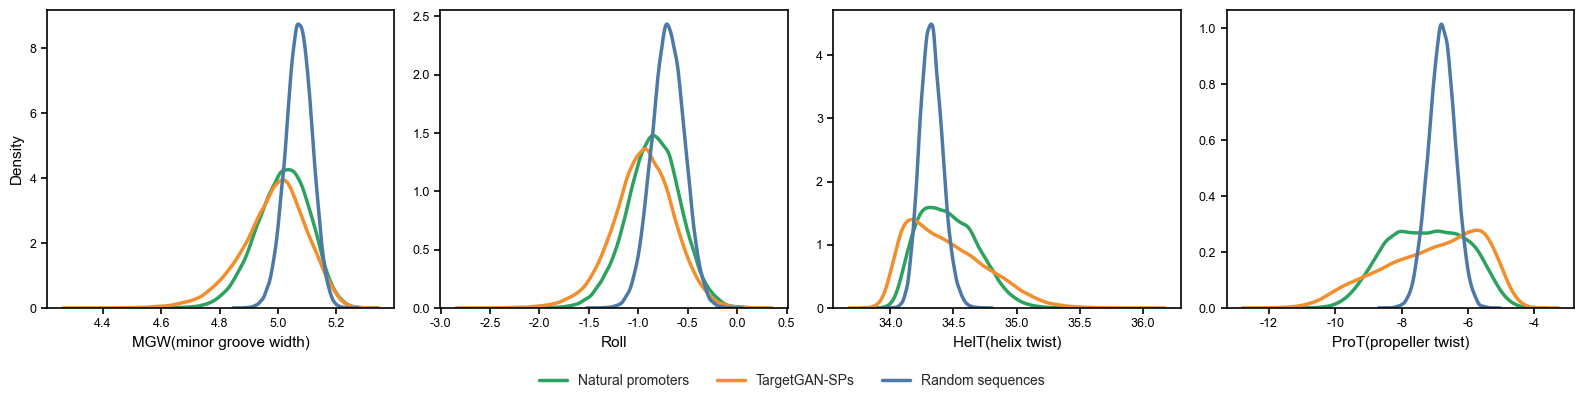

In [13]:
# --- TargetGAN / Natural promoters / Random DNA shape distribution (robust + faster) ---
import os
from functools import lru_cache
from pathlib import Path
from typing import List
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_theme(style="ticks")

save_dir = "./data_for_plot"
os.makedirs(save_dir, exist_ok=True)

# Configure where the shape files live.
# Priority: env var TARGETGAN_SHAPE_BASE > a few common local paths.
def resolve_base_path() -> str:
    env = os.environ.get("TARGETGAN_SHAPE_BASE", "").strip()
    candidates = [
        env,
        "/dev_16T1/xlxiang/xxl_desktop/xlxiang/last_TargetGAN/sup_analysis",
        # Add your local path here if needed.
    ]
    for c in candidates:
        if not c:
            continue
        if Path(c).exists():
            return c
    raise FileNotFoundError(
        "DNA-shape base path not found. Set env var TARGETGAN_SHAPE_BASE to the folder that contains "
        "native_shape/ targetgan_shape/ random_shape (and possibly subfolders 1..N)."
    )

base_path = resolve_base_path()

@lru_cache(maxsize=None)
def _read_non_header_lines(file_path: str) -> List[str]:
    with open(file_path, "r") as f:
        return [line.strip() for line in f if line and not line.startswith(">")]

def _parse_csv_floats(line: str) -> List[float]:
    # Files are comma-separated floats with possible 'NA' tokens.
    out: List[float] = []
    for tok in line.split(","):
        tok = tok.strip()
        if not tok or tok == "NA":
            continue
        try:
            out.append(float(tok))
        except ValueError:
            # Ignore malformed tokens quietly to be resilient to formatting quirks.
            continue
    return out

def process_shape_files(shape_type: str, file_type: str, *, num_splits: int = 6, lines_per_seq: int = 11) -> np.ndarray:
    """
    Read DNA shape data and return per-sequence means.

    Supported directory layouts under base_path:
      - base_path/<folder_name>/<shape_type> (single file)
      - base_path/<folder_name>/<i>/<shape_type> (split files, i=1..num_splits)

    file_type mapping:
      - 'np' -> 'native_shape'
      - otherwise -> f"{file_type}_shape"
    """
    if file_type.lower() == "np":
        folder_name = "native_shape"
    else:
        folder_name = f"{file_type}_shape"

    folder = Path(base_path) / folder_name
    if not folder.exists():
        return np.asarray([], dtype=float)

    # Prefer the single-file layout if present to avoid duplicate reads across split indices.
    direct = folder / shape_type
    candidate_files: List[Path] = []
    if direct.exists():
        candidate_files = [direct]
    else:
        for i in range(1, num_splits + 1):
            p = folder / str(i) / shape_type
            if p.exists():
                candidate_files.append(p)

    all_means: List[float] = []
    for fp in candidate_files:
        try:
            lines = _read_non_header_lines(str(fp))
        except OSError:
            continue

        current_vals: List[float] = []
        for idx, line in enumerate(lines, 1):
            current_vals.extend(_parse_csv_floats(line))
            if idx % lines_per_seq == 0:
                if current_vals:
                    all_means.append(float(np.mean(current_vals)))
                current_vals = []
        # Handle trailing lines if file doesn't end exactly at a sequence boundary.
        if current_vals:
            all_means.append(float(np.mean(current_vals)))

    return np.asarray(all_means, dtype=float)

shape_types = ["MGW", "Roll", "HelT", "ProT"]
labels_map = {
    "MGW": "MGW(minor groove width)",
    "Roll": "Roll",
    "HelT": "HelT(helix twist)",
    "ProT": "ProT(propeller twist)",
}

# Palette to match the figure
colors = {
    "NP": "#2ca25f",
    "Target": "#f28e2b",
    "Random": "#4e79a7",
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plt.subplots_adjust(wspace=0.35)

for idx, shape in enumerate(shape_types):
    print(f"Processing shape: {shape} ...")
    ax = axes[idx]

    # Read Data: TargetGAN, NP, Random
    target_data = process_shape_files(shape, "targetgan", num_splits=6)
    np_data = process_shape_files(shape, "np", num_splits=6)
    random_data = process_shape_files(shape, "random", num_splits=6)

    # Plot KDEs (guard against empty/degenerate arrays)
    if np_data.size > 1 and np.nanstd(np_data) > 0:
        sns.kdeplot(np_data, color=colors["NP"], lw=2.5, label="Natural promoters", ax=ax, warn_singular=False)
    if target_data.size > 1 and np.nanstd(target_data) > 0:
        sns.kdeplot(target_data, color=colors["Target"], lw=2.5, label="TargetGAN-SPs", ax=ax, warn_singular=False)
    if random_data.size > 1 and np.nanstd(random_data) > 0:
        sns.kdeplot(random_data, color=colors["Random"], lw=2.5, label="Random sequences", ax=ax, warn_singular=False)

    ax.set_title("")
    ax.set_xlabel(labels_map[shape], fontsize=11, fontname="Arial", color="black", fontweight="normal")

    if idx == 0:
        ax.set_ylabel("Density", fontsize=11, fontname="Arial", color="black")
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="both", which="major", labelsize=9, width=1.2, length=4, colors="black")
    for lab in ax.get_xticklabels() + ax.get_yticklabels():
        lab.set_fontname("Arial")

    for spine_name in ["top", "right", "bottom", "left"]:
        ax.spines[spine_name].set_visible(True)
        ax.spines[spine_name].set_linewidth(1.2)
        ax.spines[spine_name].set_color("black")

legend_handles = [
    Line2D([0], [0], color=colors["NP"], lw=2.5, label="Natural promoters"),
    Line2D([0], [0], color=colors["Target"], lw=2.5, label="TargetGAN-SPs"),
    Line2D([0], [0], color=colors["Random"], lw=2.5, label="Random sequences"),
 ]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## 3.6. Target-wise Feature Analysis
From this point onward, all analyses are performed **separately for each activity target** to visualize target-dependent changes in sequence grammar, diversity/composition, and DNA shape features.

### Target-wise K-mer Frequency Correlation
Computing and visualizing **6-mer** frequency correlations between natural promoters and TargetGAN synthetic promoters separately for each activity target to inspect target-dependent motif shifts.

Generating scatter plots for all targets...


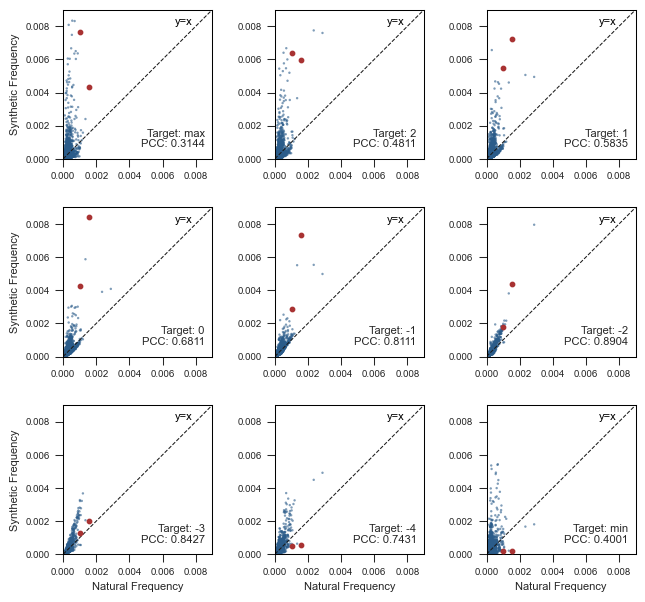

In [14]:
target_path = '../data/targetgan_55296.xlsx'
df_syn = pd.read_excel(target_path)
# Definition of all targets (including 'max')
all_targets = ['max', '2', '1', '0', '-1', '-2', '-3', '-4', 'min']

# Setup grid for plots (3 rows x 3 cols)
# A4 portrait size (approx 8.27 x 11.69 inches)
n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8.27, 11.69))
axes = axes.flatten()

print("Generating scatter plots for all targets...")

for i, target in enumerate(all_targets):
    ax = axes[i]
    
    # 1. Filter data for the specific target
    # Ensure target column is treated as string for matching
    df_sub = df_syn[df_syn['target'].astype(str) == str(target)]
    generated_seqs_sub = list(df_sub.sequence.dropna())
    
    if len(generated_seqs_sub) == 0:
        ax.text(0.5, 0.5, f"No sequences for Target {target}", ha='center', va='center', fontsize=6)
        continue
        
    # 2. Calculate 6-mer Frequencies
    # (accumulated_vector_natural is reused from previous cell)
    accumulated_vector_generated_sub = accumulate_kmer_frequencies(generated_seqs_sub, 6)
    
    # 3. Calculate Pearson Correlation
    pcc_sub, _ = pearsonr(accumulated_vector_natural, accumulated_vector_generated_sub)
    
    # 4. Plotting
    # Scatter Plot
    ax.scatter(accumulated_vector_natural, accumulated_vector_generated_sub, 
               s=3, c='#2b5c8a', alpha=0.6, edgecolors='none')
    
    # Diagonal Line
    limit = 0.009
    ax.plot([0, limit], [0, limit], 'k--', linewidth=0.75)
    
    # Add 'y=x' label
    # Moved slightly left (0.8 -> 0.75) to avoid overlap
    ax.text(0.75, 0.9, 'y=x', transform=ax.transAxes, fontsize=8, color='black')
    
    # Highlight TATA boxes (Only points, no text/arrows)
    # Coordinates
    x_tataaa, y_tataaa = accumulated_vector_natural[idx_tataaa], accumulated_vector_generated_sub[idx_tataaa]
    x_tatata, y_tatata = accumulated_vector_natural[idx_tatata], accumulated_vector_generated_sub[idx_tatata]
    
    # Keep size 10 red points
    ax.scatter(x_tataaa, y_tataaa, s=10, c=highlight_color, zorder=10)
    ax.scatter(x_tatata, y_tatata, s=10, c=highlight_color, zorder=10)
    
    # Annotations (Target Name and PCC)
    # Removed bold from Target, kept size 8 matching PCC
    ax.text(0.95, 0.15, f'Target: {target}', transform=ax.transAxes, fontsize=8, ha='right')
    ax.text(0.95, 0.08, f'PCC: {pcc_sub:.4f}', transform=ax.transAxes, fontsize=8, ha='right')
    
    # Axis settings
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_aspect('equal', adjustable='box') 
    
    # Only label outer axes
    if i % n_cols == 0:
        ax.set_ylabel('Synthetic Frequency', fontsize=8)
    if i >= n_cols * (n_rows - 1):
        ax.set_xlabel('Natural Frequency', fontsize=8)
        
    # Retain all borders and set linewidth to 0.75
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.75)
        spine.set_color('black')

    # Tick params minimum 6
    ax.tick_params(width=0.75, labelsize=7)

# Use tight_layout to place content in the upper-middle part of A4 page with margins
# rect=[left, bottom, right, top]
# Reduced side margins (0.15 -> 0.10) to make plots larger
# Adjusted bottom (0.45 -> 0.40) to maintain roughly square aspect for the grid area relative to page width
plt.tight_layout(rect=[0.10, 0.40, 0.90, 0.96], w_pad=1.5, h_pad=1.5)
plt.show()

### Sequence Diversity (Jaccard, Levenshtein) and GC Content by Target
Analyzing target-wise sequence diversity and composition by comparing Jaccard distance, Levenshtein distance, and GC content across all activity targets, with natural promoters as the reference baseline.

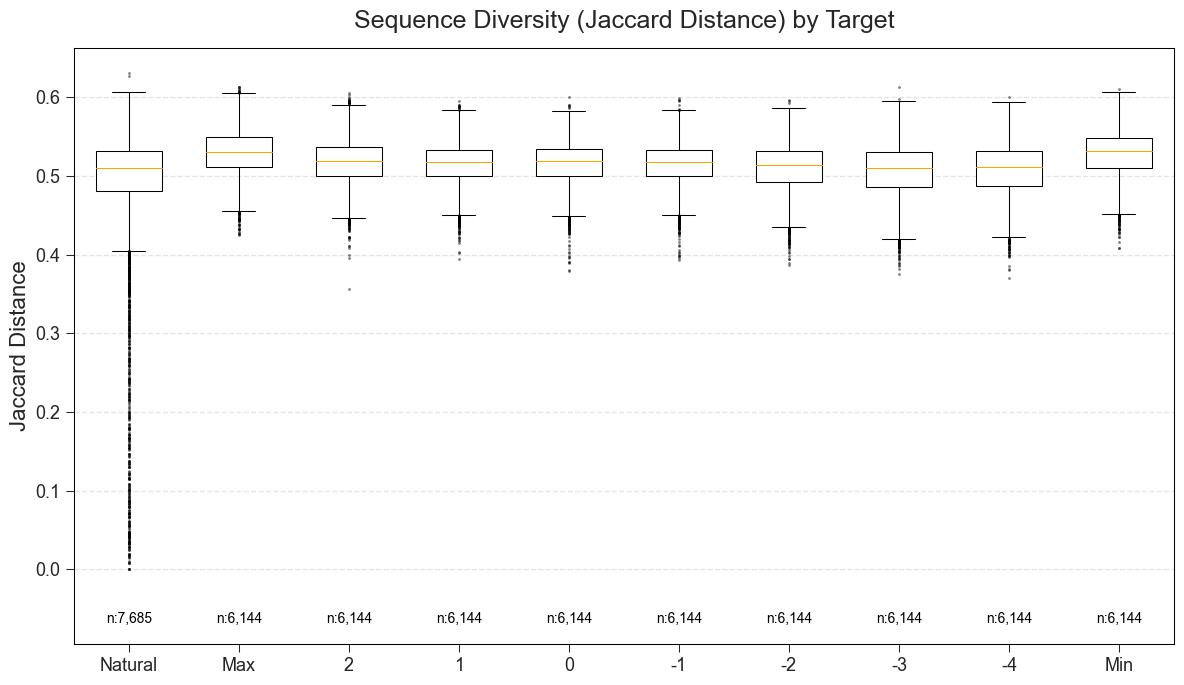

In [15]:
# Sequence Diversity by Target (Jaccard Distance)

# 1. Load Data
save_dir = './data_for_plot'



# Load Jaccard Data
# Natural Promoters
test_jaccard = np.load(os.path.join(save_dir, 'test_jaccard.npy'))
# TargetGAN Promoters (All targets concatenated)
target_jaccard = np.load(os.path.join(save_dir, 'target_jaccard.npy'))

# 2. Slice Data for Each Target (Using df_syn filtering)
targets_order = ['max', '2', '1', '0', '-1', '-2', '-3', '-4', 'min']

all_jaccard_data = [test_jaccard]
labels = ['Natural']

# Align target_jaccard with df_syn (assuming row-to-row correspondence)
# Add jaccard data to dataframe for easier filtering
if len(target_jaccard) == len(df_syn):
    df_syn['jaccard_dist'] = target_jaccard
    
    for target in targets_order:
        # Filter by target column
        subset = df_syn[df_syn['target'].astype(str) == str(target)]['jaccard_dist'].values
        
        all_jaccard_data.append(subset)
        
        # Label formatting
        label = target.capitalize() if target in ['max', 'min'] else target
        labels.append(label)
else:
    print(f"Warning: Length mismatch. target_jaccard: {len(target_jaccard)}, df_syn: {len(df_syn)}")
    # Fallback or empty if mismatch
    for target in targets_order:
        all_jaccard_data.append([])
        label = target.capitalize() if target in ['max', 'min'] else target
        labels.append(label)

# 3. Plotting
plt.figure(figsize=(12, 7))

# Style settings consistent with other plots (0.75 linewidth)
boxprops = dict(facecolor='white', edgecolor='black', linewidth=0.75)
medianprops = dict(color='orange', linewidth=0.75)
whiskerprops = dict(color='black', linewidth=0.75)
capprops = dict(color='black', linewidth=0.75)
flierprops = dict(marker='o', markersize=2, markerfacecolor='black', markeredgecolor='none', alpha=0.5)

ax = plt.gca()
plt.boxplot(all_jaccard_data, 
            labels=labels,
            patch_artist=True,
            showfliers=True,
            boxprops=boxprops,
            medianprops=medianprops,
            whiskerprops=whiskerprops,
            capprops=capprops,
            flierprops=flierprops,
            widths=0.6)

# Aesthetics
plt.ylabel('Jaccard Distance', fontsize=16)
plt.title('Sequence Diversity (Jaccard Distance) by Target', fontsize=18, fontweight='bold', y=1.02)
plt.tick_params(axis='both', which='major', labelsize=13, width=0.75)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Calculate limits to avoid text overlap
def safe_min(a): return np.min(a) if len(a) > 0 else 0
def safe_max(a): return np.max(a) if len(a) > 0 else 1

min_val = min([safe_min(d) for d in all_jaccard_data])
max_val = max([safe_max(d) for d in all_jaccard_data])
rng = max_val - min_val

# Position text below the lowest data point
text_y_pos = min_val - (rng * 0.1)
ax.set_ylim(bottom=text_y_pos - (rng * 0.05), top=max_val + (rng * 0.05))

# Annotate counts (n: ...)
for i, data in enumerate(all_jaccard_data):
    count = len(data)
    plt.text(i+1, text_y_pos, f"n:{count:,}", ha='center', va='center', fontsize=10, color='black')

# Enforce full borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
    spine.set_color('black')

plt.tight_layout()
plt.show()

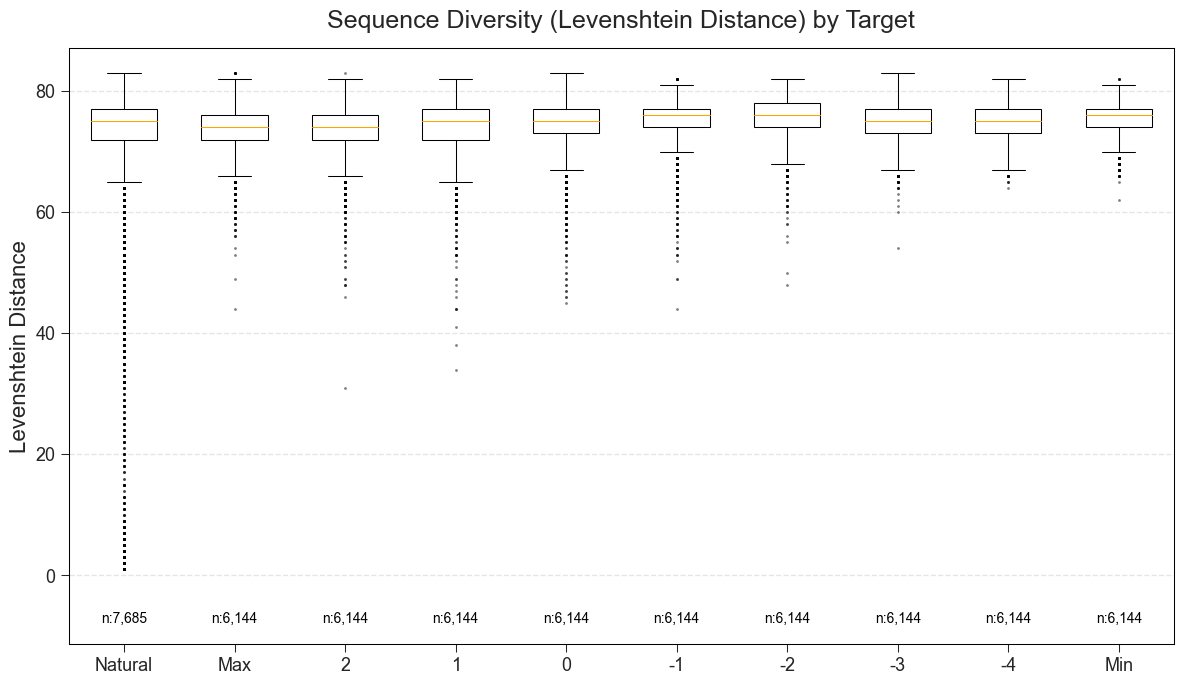

In [16]:
# Sequence Diversity by Target (Levenshtein Distance)

# 1. Load Data
save_dir = './data_for_plot'

# Load Levenshtein Data
# Natural Promoters
test_levenshtein = np.load(os.path.join(save_dir, 'test_levenshtein.npy'))
# TargetGAN Promoters (All targets concatenated)
target_levenshtein = np.load(os.path.join(save_dir, 'target_levenshtein.npy'))

# 2. Slice Data for Each Target (Using df_syn filtering)
targets_order = ['max', '2', '1', '0', '-1', '-2', '-3', '-4', 'min']

all_levenshtein_data = [test_levenshtein]
labels = ['Natural']

# Align target_levenshtein with df_syn (assuming row-to-row correspondence)
if len(target_levenshtein) == len(df_syn):
    df_syn['levenshtein_dist'] = target_levenshtein
    
    for target in targets_order:
        # Filter by target column
        subset = df_syn[df_syn['target'].astype(str) == str(target)]['levenshtein_dist'].values
        
        all_levenshtein_data.append(subset)
        
        # Label formatting
        label = target.capitalize() if target in ['max', 'min'] else target
        labels.append(label)
else:
    print(f"Warning: Length mismatch. target_levenshtein: {len(target_levenshtein)}, df_syn: {len(df_syn)}")
    # Fallback to chunk slicing if lengths don't match or df_syn is unavailable
    # This assumes standard block size if alignment fails
    chunk_size = 6144
    for i, target in enumerate(targets_order):
        start = i * chunk_size
        end = (i + 1) * chunk_size
        if start < len(target_levenshtein):
            subset = target_levenshtein[start:min(end, len(target_levenshtein))]
            all_levenshtein_data.append(subset)
        else:
            all_levenshtein_data.append([])
            
        label = target.capitalize() if target in ['max', 'min'] else target
        labels.append(label)

# 3. Plotting
plt.figure(figsize=(12, 7))

# Style settings consistent with other plots (0.75 linewidth)
boxprops = dict(facecolor='white', edgecolor='black', linewidth=0.75)
medianprops = dict(color='orange', linewidth=0.75)
whiskerprops = dict(color='black', linewidth=0.75)
capprops = dict(color='black', linewidth=0.75)
flierprops = dict(marker='o', markersize=2, markerfacecolor='black', markeredgecolor='none', alpha=0.5)

ax = plt.gca()
plt.boxplot(all_levenshtein_data, 
            labels=labels,
            patch_artist=True,
            showfliers=True,
            boxprops=boxprops,
            medianprops=medianprops,
            whiskerprops=whiskerprops,
            capprops=capprops,
            flierprops=flierprops,
            widths=0.6)

# Aesthetics
plt.ylabel('Levenshtein Distance', fontsize=16)
plt.title('Sequence Diversity (Levenshtein Distance) by Target', fontsize=18, fontweight='bold', y=1.02)
plt.tick_params(axis='both', which='major', labelsize=13, width=0.75)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Calculate limits to avoid text overlap
def safe_min(a): return np.min(a) if len(a) > 0 else 0
def safe_max(a): return np.max(a) if len(a) > 0 else 0

# Adjust scaling logic for Levenshtein (values are larger, integers)
min_val = min([safe_min(d) for d in all_levenshtein_data])
max_val = max([safe_max(d) for d in all_levenshtein_data])
rng = max_val - min_val

# Position text below the lowest data point
text_y_pos = min_val - (rng * 0.1)
ax.set_ylim(bottom=text_y_pos - (rng * 0.05), top=max_val + (rng * 0.05))

# Annotate counts (n: ...)
for i, data in enumerate(all_levenshtein_data):
    count = len(data)
    plt.text(i+1, text_y_pos, f"n:{count:,}", ha='center', va='center', fontsize=10, color='black')

# Enforce full borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
    spine.set_color('black')

plt.tight_layout()
plt.show()

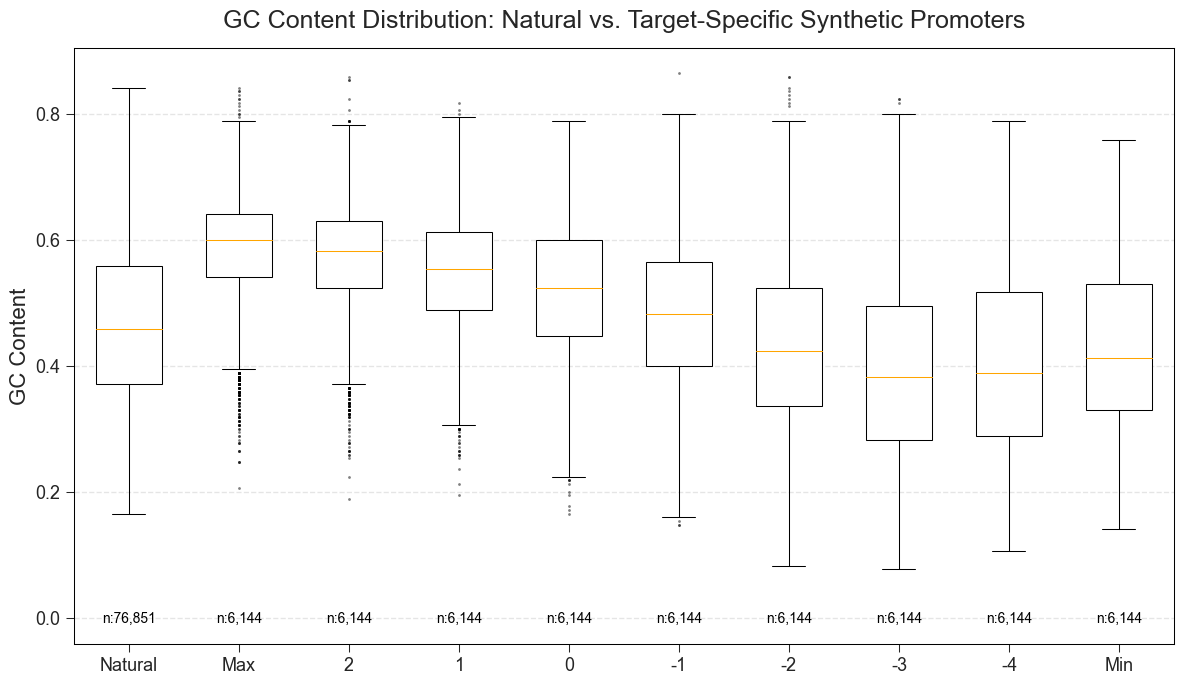

In [17]:
# GC Content Separation by Target

# 1. Prepare Data
# Natural Promoters (from previous cells)
gc_natural = [gc_content(s) for s in natural_seqs]

# Targets
targets_order = ['max', '2', '1', '0', '-1', '-2', '-3', '-4', 'min']
all_gc_data = [gc_natural]
labels = ['Natural']

for target in targets_order:
    # Filter
    df_sub = df_syn[df_syn['target'].astype(str) == str(target)]
    seqs = list(df_sub.sequence.dropna())
    
    # Calculate GC
    if seqs:
        gc_vals = [gc_content(s) for s in seqs]
    else:
        gc_vals = []
        
    all_gc_data.append(gc_vals)
    
    # Label formatting
    label = target.capitalize() if target in ['max', 'min'] else target
    labels.append(label)

# 2. Plotting
plt.figure(figsize=(12, 7))

# Style - Set linewidth to 0.75 as requested
boxprops = dict(facecolor='white', edgecolor='black', linewidth=0.75)
medianprops = dict(color='orange', linewidth=0.75)
whiskerprops = dict(color='black', linewidth=0.75)
capprops = dict(color='black', linewidth=0.75)
flierprops = dict(marker='o', markersize=2, markerfacecolor='black', markeredgecolor='none', alpha=0.5)

ax = plt.gca()
plt.boxplot(all_gc_data, 
            labels=labels,
            patch_artist=True,
            showfliers=True,
            boxprops=boxprops,
            medianprops=medianprops,
            whiskerprops=whiskerprops,
            capprops=capprops,
            flierprops=flierprops,
            widths=0.6)

# Aesthetics
plt.ylabel('GC Content', fontsize=16)
plt.title('GC Content Distribution: Natural vs. Target-Specific Synthetic Promoters', fontsize=18, fontweight='bold', y=1.02)
plt.tick_params(axis='both', which='major', labelsize=13, width=0.75)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Calculate limits to avoid overlap
# Find global minimum data point
min_data_val = min([min(d) if len(d) > 0 else 0.0 for d in all_gc_data])
max_data_val = max([max(d) if len(d) > 0 else 1.0 for d in all_gc_data])
data_range = max_data_val - min_data_val

# Position text below the lowest data point
text_y_pos = min_data_val - (data_range * 0.1)

# Set grid limits to include the text
ax.set_ylim(bottom=text_y_pos - (data_range * 0.05), top=max_data_val + (data_range * 0.05))

# Annotate counts
for i, data in enumerate(all_gc_data):
    count = len(data)
    plt.text(i+1, text_y_pos, f"n:{count:,}", ha='center', va='center', fontsize=10, color='black')

# Enforce full borders (remove sns.despine and set spines explicitly)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.75)
    spine.set_color('black')

plt.tight_layout()
plt.show()

### DNA Shape Features by Target
Comparing DNA shape features (**MGW**, **Roll**, **HelT**, **ProT**) across activity targets to assess whether structural properties shift with the desired activity level.

Loading MGW...


Loading Roll...
Loading HelT...
Loading ProT...


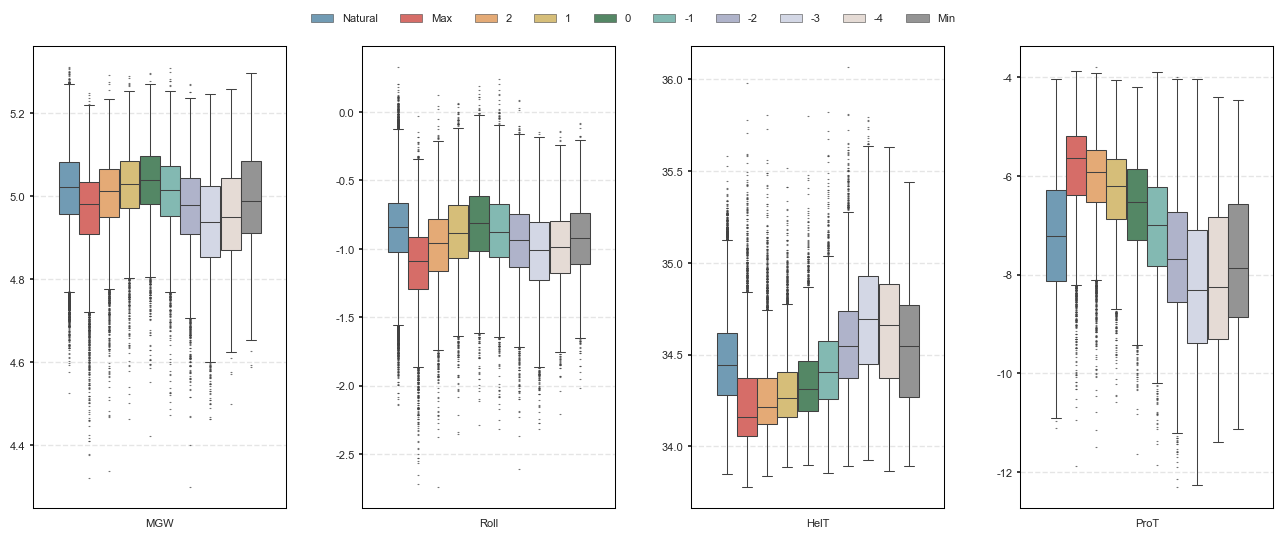

In [20]:
# DNA Shape Analysis by Target (Grouped Subplots with Independent Y-Axes)

# 1. Configuration
base_path = '/dev_16T1/xlxiang/xxl_desktop/xlxiang/last_TargetGAN/sup_analysis'
targets_order = ['max', '2', '1', '0', '-1', '-2', '-3', '-4', 'min']
shape_types = ['MGW', 'Roll', 'HelT', 'ProT']
# Map labels not used for Y-label anymore per request, but kept for reference
labels_map = {
    'MGW': 'MGW (Å)',
    'Roll': 'Roll (°)',
    'HelT': 'HelT (°)',
    'ProT': 'ProT (°)'
}
chunk_size = 6144

# Define colors for targets (Natural + TargetGAN targets)
palette_dict = {
    'Natural': '#669ebf',
    'Max': '#E85D56',
    '2': '#F6A964',
    '1': '#E5C66A',
    '0': '#4B8F62',
    '-1': '#7AC2B9',    
    '-2': '#AAB0CF',
    '-3': '#D0D5E8',
    '-4': '#E7DBD3',
    'Min': '#949494'
}

# 2. Data Reading Function
def read_shape_data(folder_name, shape_type, num_files=8):
    all_vals = []
    if not os.path.exists(base_path): return []
    for i in range(num_files):
        file_path = os.path.join(base_path, folder_name, str(i+1), shape_type)
        if not os.path.exists(file_path): continue
        try:
            with open(file_path, 'r') as f:
                lines = [line.strip() for line in f if not line.startswith('>')]
            current = []
            for idx, line in enumerate(lines, 1):
                vals = [float(x) for x in line.split(',') if x != 'NA']
                current.extend(vals)
                if idx % 11 == 0:
                    if current: all_vals.append(np.mean(current))
                    current = []
        except: pass
    return all_vals

# 3. Process All Data into DataFrame (to use Hue grouping)
data_list = []
for shape in shape_types:
    print(f"Loading {shape}...")
    
    # Natural
    native_vals = read_shape_data('native_shape', shape)
    if native_vals:
        for v in native_vals:
            data_list.append({'Shape': shape, 'Target': 'Natural', 'Value': v})

    # TargetGAN
    targetgan_all = read_shape_data('targetgan_shape', shape)
    if targetgan_all:
        for i, target in enumerate(targets_order):
            start = i * chunk_size
            end = (i + 1) * chunk_size
            if start < len(targetgan_all):
                subset = targetgan_all[start:min(end, len(targetgan_all))]
                # Format Label
                label = target.capitalize() if target in ['max', 'min'] else target
                for v in subset:
                    data_list.append({'Shape': shape, 'Target': label, 'Value': v})

df_shape = pd.DataFrame(data_list)

# 4. Plotting
if not df_shape.empty:
    # Use 1x4 subplots, visually grouped
    fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=False) 
    
    # Adjust spacing
    plt.subplots_adjust(wspace=0.3) 

    # Plot Order for Hue
    hue_order = ['Natural', 'Max', '2', '1', '0', '-1', '-2', '-3', '-4', 'Min']

    for idx, shape in enumerate(shape_types):
        ax = axes[idx]
        
        # Filter data for this shape
        df_sub = df_shape[df_shape['Shape'] == shape]
        
        if df_sub.empty:
            continue
            
        # Plot Boxplot
        sns.boxplot(data=df_sub, x='Shape', y='Value', hue='Target', 
                    hue_order=hue_order,
                    palette=palette_dict,
                    ax=ax,
                    linewidth=0.75,
                    fliersize=0.2, # Reduced flier size from 1 to 0.2
                    width=0.8) 
                    
        # Styling
        ax.set_title("") 
        
        # X-label (Shape name) - Font size 8
        ax.set_xlabel(shape, fontsize=8, fontweight='bold')
        
        # Y-label (Empty per request)
        ax.set_ylabel("", fontsize=8)
        
        # Remove X-ticks text since X-label is the Shape name
        ax.set_xticklabels([])
        
        # Update tick parameters - Font size 8 for Y-ticks
        ax.tick_params(axis='both', which='major', labelsize=8, length=2)
        ax.tick_params(axis='x', length=0) # No x ticks
        
        # Grid
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Remove Legend from subplot
        if ax.get_legend():
            ax.legend_.remove()
            
        # Borders
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.75)
            spine.set_color('black')

    # Create a single legend outside the plots
    # Font size 8
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=10, frameon=False, fontsize=8)
    plt.show()
else:
    print("No shape data accumulated.")